# Ridge: 1피처와 2피처의 Validation / Test 비교

첨부 `종합실습_가이드_모델개발및최적화_장수영.ipynb`의 **fit → predict → evaluate → 비교표** 흐름을
배터리 수명 회귀에 맞췄습니다. 위에서 아래로 실행하면 초반에 바로 `=== Validation 평가 ===`가 나오고,
이후 두 피처 구성의 결과를 같은 조건에서 비교할 수 있습니다.

**과제의 Train / Valid / Test / GAP 6행 표는 맨 아래 「부록 B. 과제 제출용 성능 결과」에서 확인합니다.**

| 구성 | 모델 입력 |
|---|---|
| 1 feature | `log10_delta_q_var` |
| 2 features | `log10_delta_q_var` + `SOC_switch_pct` |

정답은 총수명 `cycle_life`이며 원래 사이클 단위 그대로 학습합니다. 모델은 두 구성 모두 **Ridge**입니다.
피처 근거: [Notion 보고서](https://app.notion.com/p/3ecd54b5a6d7818f99bde98f1cef9db1).

첨부의 AUC는 분류 지표입니다. 여기서는 **MAPE(%)가 낮을수록**, **R²가 높을수록** 좋습니다.
배터리 실험은 충전 정책 그룹을 기준으로 분할합니다.

<details>
<summary>첨부한 종합실습 노트북은 어떤 흐름인가요?</summary>

1. 은행 고객의 이탈 여부 `Exited`(0 또는 1)를 예측하는 **분류** 실습입니다. 데이터를 Train 60%, Validation 20%, Test 20%로 분할합니다.
2. DecisionTree를 학습하고, `predict`로 이탈 여부를, `predict_proba`로 이탈 확률을 구합니다. `evaluate()`가 Validation·Test의 Accuracy, F1, Recall, Precision, AUC를 출력합니다.
3. 추가 실험에서는 HistGradientBoosting·GradientBoosting의 설정을 Validation AUC로 탐색하고, 두 모델의 확률을 합친 앙상블도 비교합니다.
4. 마지막에는 모델별 Validation·Test 지표를 한 표로 보여줍니다. 이 노트북도 평가 함수와 최종 표를 같은 위치에서 찾을 수 있게 구성했습니다.

우리 정답은 연속값인 **총수명**이므로 `predict`의 결과도 사이클 수입니다. AUC는 양성·음성을 구분하는 점수이고,
MAPE는 수명 예측의 평균 상대 오차입니다. 예를 들어 실제 1,000사이클을 900사이클로 예측한 셀의 상대 오차는 10%입니다.
MAPE 7%를 정확도 93%로 해석하지 않습니다.

지표 정의: [AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html),
[MAPE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_percentage_error.html).
첨부의 은행 실습 조건은 해당 예제의 설명이며, 이 배터리 실험의 데이터·평가 규칙은 아래에 별도로 표시합니다.

</details>

실행은 **Restart Kernel → Run All** 순서로 시작하세요. 커널을 새로 시작하면 이전 변수는 사라집니다.
모든 실행에서 원본 MAT에서 입력을 준비하며, `SAVE_OUTPUTS=False`에서는 별도 결과 폴더를 만들지 않습니다.

## 1. 준비

Batch 1 개발 36셀에서 CV로 설정을 선택하고, Batch 1 hold-out 10셀을 Validation으로 평가합니다.
그 뒤 같은 설정으로 Batch 1 전체 46셀을 재학습하여 Batch 2의 39셀을 Test로 평가합니다.
두 구성은 **같은 셀과 같은 CV 폴드**를 사용합니다.

In [1]:
from pathlib import Path
import hashlib
import json
import re

import h5py

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

FEATURE_SETS = {
    "1 feature": ["log10_delta_q_var"],
    "2 features": ["log10_delta_q_var", "SOC_switch_pct"],
}
ALL_FEATURES = FEATURE_SETS["2 features"]
TARGET = "cycle_life"
SEED = 20261002
ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]
PAPER_TARGET_MAPE = 9.1
SAVE_OUTPUTS = False  # True일 때만 CSV·모델·그림을 별도로 저장합니다.
ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
             if (p / "data/2017-05-12_batchdata_updated_struct_errorcorrect.mat").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("원본 data/ 폴더가 있는 archive 프로젝트 내부에서 실행하세요.")
BATCH_FILES = {
    "B1": ROOT / "data/2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "B2": ROOT / "data/2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "B3": ROOT / "data/2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}
missing_files = [str(path) for path in BATCH_FILES.values() if not path.is_file()]
if missing_files:
    raise FileNotFoundError("원본 MAT 파일 누락: " + ", ".join(missing_files))
OUT = ROOT / "Modeling/results/ridge_1vs2_validation"
if SAVE_OUTPUTS:
    OUT.mkdir(parents=True, exist_ok=True)
print("별도 결과 저장:", SAVE_OUTPUTS)


Matplotlib is building the font cache; this may take a moment.


별도 결과 저장: False


## 2. 데이터 준비

한 행은 배터리 셀 하나입니다.
`log10_delta_q_var = log10(Var(Q100(V) − Q10(V)))`는 실제 10·100사이클 방전곡선 변화의 로그 분산입니다.
`SOC_switch_pct=80`은 정책에 표기된 SOC 80%입니다. 두 C-rate가 같으면 그 지점에서 전류가 달라지지는 않습니다. 예측 시점은 **100사이클 관측 후**입니다.

매번 원본 MAT에서 수명·충전 정책·ΔQ 피처를 직접 준비합니다.
EDA 노트북을 먼저 실행할 필요가 없고, 기존 CSV 유무와 관계없이 같은 원본 추출 과정을 사용합니다.
아래 보조 추출 코드는 펼쳐서 읽을 수 있습니다.

In [2]:
def raw_delta_q_feature(file, batch, cell_id):
    summary = file[np.asarray(batch["summary"]).reshape(-1)[cell_id]]
    cycles = file[np.asarray(batch["cycles"]).reshape(-1)[cell_id]]
    actual = np.asarray(summary["cycle"], dtype=float).reshape(-1)
    assert np.isfinite(actual).all() and np.equal(actual, np.floor(actual)).all(), "invalid_cycle_numbers"
    assert np.all(np.diff(actual) > 0), "cycle_numbers_not_unique_and_increasing"
    assert len(actual) == int(np.prod(cycles["Qdlin"].shape)), "summary_Qdlin_cycle_mismatch"
    positions = [np.flatnonzero(actual == cycle) for cycle in (10, 100)]
    assert all(len(position) == 1 for position in positions), "actual_cycle_10_or_100_missing"
    refs = np.asarray(cycles["Qdlin"]).reshape(-1)
    q10, q100 = [np.asarray(file[refs[int(position[0])]], dtype=float).reshape(-1)
                 for position in positions]
    voltage_ref = np.asarray(batch["Vdlin"]).reshape(-1)[cell_id]
    voltage = np.asarray(file[voltage_ref], dtype=float).reshape(-1)
    assert len(q10) == len(q100) == len(voltage) == 1000, "grid_length_not_1000"
    assert all(np.isfinite(vector).all() for vector in [q10, q100, voltage]), "nonfinite_curve_or_grid"
    assert np.all(np.diff(voltage) > 0) or np.all(np.diff(voltage) < 0), "voltage_not_monotonic"
    assert np.ptp(q10) > 0 and np.ptp(q100) > 0, "placeholder_discharge_curve"
    variance = float(np.var(q100 - q10, ddof=0))
    assert np.isfinite(variance) and variance > 0, "invalid_variance"
    return float(np.log10(variance))

POLICY_PATTERN = re.compile(
    r"^\s*(?P<C1>\d+(?:\.\d+)?)\s*C\s*\(\s*(?P<SOC>\d+(?:\.\d+)?)\s*%\s*\)\s*-\s*"
    r"(?P<C2>\d+(?:\.\d+)?)\s*C(?P<suffix>.*)$", re.IGNORECASE)

<details><summary>원본 MAT에서 ΔQ 피처 계산</summary>

원본에서 실제 사이클 번호 10과 100의 방전곡선을 찾아 `Q100−Q10`의 분산을 계산합니다.
1000점 곡선과 전압 축을 확인하고 `ddof=0`으로 분산을 구한 뒤 `log10`을 취합니다.
이 함수는 매번 실행되며 원본 MAT는 읽기 모드로만 엽니다.

</details>

In [3]:
def load_raw_inputs():
    rows = []
    for batch_id, path in BATCH_FILES.items():
        with h5py.File(path, "r") as file:
            batch = file["batch"]
            refs = {name: np.asarray(batch[name]).reshape(-1)
                    for name in ["cycle_life", "policy_readable", "summary", "cycles", "Vdlin"]}
            assert len({len(values) for values in refs.values()}) == 1, "cell_reference_count_mismatch"
            for cell_id in range(len(refs["summary"])):
                life = float(np.asarray(file[refs["cycle_life"][cell_id]]).reshape(-1)[0])
                policy = "".join(chr(int(value)) for value in np.asarray(file[refs["policy_readable"][cell_id]]).reshape(-1))
                row = {"cell_uid": f"{batch_id}_{cell_id}", "batch_id": batch_id,
                       "cycle_life": life if np.isfinite(life) and life > 0 else np.nan,
                       "charging_policy": policy, "log10_delta_q_var": np.nan, "dq_status": "not_read",
                       "SOC_switch_pct": np.nan, "C1": np.nan, "C2": np.nan, "policy_suffix": ""}
                match = POLICY_PATTERN.fullmatch(policy)
                if match:
                    row["policy_suffix"] = match["suffix"].strip()
                    c1, soc, c2 = float(match["C1"]), float(match["SOC"]), float(match["C2"])
                    if c1 > 0 and c2 > 0 and 0 < soc <= 80:
                        row.update(C1=c1, SOC_switch_pct=soc, C2=c2)
                try:
                    row.update(log10_delta_q_var=raw_delta_q_feature(file, batch, cell_id), dq_status="ok")
                except (AssertionError, KeyError, IndexError, ValueError, TypeError, OSError) as error:
                    row["dq_status"] = str(error)
                rows.append(row)
    return pd.DataFrame(rows)

<details><summary>원본 MAT에서 셀 표 준비</summary>

각 셀의 수명·충전 정책·ΔQ 로그 분산을 한 행으로 모읍니다.
정책 문자열에서 C1·SOC·C2·접미사를 읽고, 실제 모델 입력은 1개 또는 2개 피처만 선택합니다.
B3는 기존 코호트 집계를 맞추기 위해 읽으며 학습·평가에는 사용하지 않습니다.
추출이 실패하면 상태를 남기고, 다음 정제 셀에서 제외 이유를 확인합니다.

</details>

In [4]:
input_mode = "원본 MAT 직접 추출"
raw_inputs = load_raw_inputs()
metadata = raw_inputs[["cell_uid", "batch_id", "cycle_life", "charging_policy"]].copy()
delta = raw_inputs[["cell_uid", "batch_id", "cycle_life", "log10_delta_q_var", "dq_status"]].copy()
current = raw_inputs[["cell_uid", "batch_id", "cycle_life", "charging_policy",
                      "SOC_switch_pct", "C1", "C2", "policy_suffix"]].copy()
print("입력 방식:", input_mode, "/ 원본 셀 수:", len(metadata))
display(metadata.head(3))

입력 방식: 원본 MAT 직접 추출 / 원본 셀 수: 139


,cell_uid,batch_id,cycle_life,charging_policy
0,B1_0,B1,1190.0,3.6C(80%)-3.6C
1,B1_1,B1,1179.0,3.6C(80%)-3.6C
2,B1_2,B1,1177.0,3.6C(80%)-3.6C


In [5]:
for name, frame in [("metadata", metadata), ("delta", delta), ("current", current)]:
    assert frame["cell_uid"].notna().all(), f"{name}: 셀 식별자 누락"
    assert frame["cell_uid"].is_unique, f"{name}: 중복 셀"
    assert set(frame["cell_uid"]) == set(metadata["cell_uid"]), f"{name}: 셀 목록 불일치"
data = metadata.merge(
    delta.rename(columns={"batch_id": "batch_delta", "cycle_life": "life_delta"}),
    on="cell_uid", how="left", validate="one_to_one",
).merge(
    current.rename(columns={"batch_id": "batch_current", "cycle_life": "life_current",
                            "charging_policy": "policy_current"}),
    on="cell_uid", how="left", validate="one_to_one",
)
for label_column in ["life_delta", "life_current"]:
    assert np.isclose(data[TARGET], data[label_column], equal_nan=True).all(), "수명 라벨 불일치"
assert data["batch_id"].eq(data["batch_delta"]).all()
assert data["batch_id"].eq(data["batch_current"]).all()
assert data["charging_policy"].eq(data["policy_current"]).all()
data = data.drop(columns=["batch_delta", "batch_current", "life_delta", "life_current", "policy_current"])

### 정제 기준

입력의 무한대는 결측값으로 바꿉니다. 유효하지 않거나 0 이하인 수명 라벨, 유효한 ΔQ 피처가 없는 셀은 제외합니다.
**정답 y는 대체하지 않습니다.** SOC 결측은 각 학습 데이터 안에서 중앙값으로 대체합니다.
두 구성은 같은 정제 기준을 적용한 공통 코호트를 사용하며, Batch 3은 학습·평가에 사용하지 않습니다.

충전 정책 `C1 + SOC + C2 + 접미사`를 정규화하여 그룹을 만듭니다.
같은 그룹을 학습과 Validation에 나눠 넣지 않습니다. 정책 그룹은 모델 입력에 포함하지 않습니다.

In [6]:
for column in ALL_FEATURES + [TARGET, "C1", "C2"]:
    data[column] = pd.to_numeric(data[column], errors="coerce").replace([np.inf, -np.inf], np.nan)
invalid_y = data[TARGET].isna() | data[TARGET].le(0)
invalid_delta = data["log10_delta_q_var"].isna() | data["dq_status"].fillna("").ne("ok")
data["eligible"] = ~(invalid_y | invalid_delta)
data["exclusion_reason"] = [
    "; ".join(reason for condition, reason in [
        (bad_y, "invalid_or_nonpositive_target"), (bad_delta, "invalid_delta_q")
    ] if condition) for bad_y, bad_delta in zip(invalid_y, invalid_delta)
]
excluded_cells = data.loc[~data["eligible"]].copy()
cohort_audit = data.groupby("batch_id").agg(
    raw_cells=("cell_uid", "size"), eligible_cells=("eligible", "sum")
).reset_index()
cohort_audit["excluded_cells"] = cohort_audit["raw_cells"] - cohort_audit["eligible_cells"]
data = data.loc[data["eligible"]].drop(columns=["eligible", "exclusion_reason"]).reset_index(drop=True)

suffix = data["policy_suffix"].fillna("none").astype(str).str.lower().str.replace(
    r"[^a-z0-9]", "", regex=True).replace("", "none")
raw_policy = data["charging_policy"].fillna("").astype(str).str.lower().str.replace(r"\s+", "", regex=True)
assert raw_policy.ne("").all(), "충전 정책 누락"
data["policy_group"] = [
    f"C1={c1:g}|SOC={soc:g}|C2={c2:g}|suffix={tail}"
    if np.isfinite([c1, soc, c2]).all() else f"raw={raw}"
    for c1, soc, c2, tail, raw in zip(data["C1"], data["SOC_switch_pct"], data["C2"], suffix, raw_policy)
]
display(cohort_audit, excluded_cells[["cell_uid", "exclusion_reason"]])

,batch_id,raw_cells,eligible_cells,excluded_cells
0,B1,46,46,0
1,B2,47,39,8
2,B3,46,44,2


,cell_uid,exclusion_reason
68,B2_22,invalid_or_nonpositive_target
69,B2_23,invalid_or_nonpositive_target
81,B2_35,invalid_or_nonpositive_target
82,B2_36,invalid_or_nonpositive_target
83,B2_37,invalid_or_nonpositive_target
84,B2_38,invalid_or_nonpositive_target
85,B2_39,invalid_or_nonpositive_target
86,B2_40,invalid_or_nonpositive_target
116,B3_23,invalid_or_nonpositive_target
125,B3_32,invalid_or_nonpositive_target


<details>
<summary>위 정제 코드 읽기: 숫자 변환, 제외 이유, 정책 그룹</summary>

1. `pd.to_numeric(..., errors="coerce")`는 숫자가 아닌 값을 `NaN`으로 바꾸고, `replace`는 무한대도 결측으로 통일합니다.
2. `invalid_y`는 수명이 결측이거나 0 이하인 셀입니다. `invalid_delta`는 ΔQ 로그 분산이 결측이거나 계산 상태가 `ok`가 아닌 셀입니다. **로그 분산의 음수 값은 정상입니다.**
3. `|`는 두 조건 중 하나라도 해당한다는 뜻이고, `~`는 반대입니다. `eligible`은 두 조건 모두 통과한 셀입니다. `zip`은 같은 셀의 두 조건을 짝지어 해당하는 제외 이유만 연결합니다.
4. `excluded_cells`에는 제외된 셀과 이유를 보관합니다. `cohort_audit`는 배치별 원본·유효·제외 셀 수를 집계합니다. True를 합하면 유효 셀 수가 됩니다.
5. `data.loc[data["eligible"]]`로 유효 셀만 남기고 행 번호를 다시 붙입니다. SOC 결측은 이 단계에서 제외하지 않고 모델의 학습 구간 안에서 중앙값으로 대체합니다.

현재 B1은 **46 → 46셀**, B2는 **47 → 39셀**, B3는 **46 → 44셀**입니다. B3는 확인용 집계입니다.
이어서 만드는 `policy_group`은 C1·SOC·C2·접미사를 정규화한 분할용 이름입니다. 구성 요소가 누락되면 공백을 제거한 원래 정책 문자열을 사용합니다.
모델 `X`에는 표에 표시한 **1개 또는 2개 피처만** 들어갑니다.

</details>

In [7]:
batch1 = data.loc[data["batch_id"].eq("B1")].copy().reset_index(drop=True)
batch2 = data.loc[data["batch_id"].eq("B2")].copy().reset_index(drop=True)
assert len(batch1) == 46 and len(batch2) == 39
assert batch1["policy_group"].nunique() == 23
display(batch1[ALL_FEATURES + [TARGET]].describe())
display(batch1[ALL_FEATURES + [TARGET]].isna().sum().rename("missing_count").to_frame())

,log10_delta_q_var,SOC_switch_pct,cycle_life
count,46.000000,46.000000,46.000000
mean,-3.923430,51.521739,844.717391
std,0.378273,19.461345,184.629198
min,-5.014861,15.000000,534.000000
25%,-4.053411,40.000000,703.250000
50%,-3.851160,50.000000,858.500000
75%,-3.668210,67.500000,914.250000
max,-3.350338,80.000000,1227.000000


,missing_count
log10_delta_q_var,0
SOC_switch_pct,0
cycle_life,0


## 3. Train / Validation / Test 준비

Batch 1의 정책 그룹 20%를 Validation으로 고정합니다. `SEED=20261002`와 정책 그룹 정의를 고정하여 재현합니다.
`X_train`, `X_valid`, `X_test`는 우선 두 피처를 담고, 모델별로 필요한 열만 선택합니다.

In [8]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, valid_idx = next(splitter.split(batch1[ALL_FEATURES], batch1[TARGET], batch1["policy_group"]))
df_train = batch1.iloc[train_idx].copy().reset_index(drop=True)
df_valid = batch1.iloc[valid_idx].copy().reset_index(drop=True)
df_test = batch2.copy()
X_train, y_train = df_train[ALL_FEATURES].copy(), df_train[TARGET].copy()
X_valid, y_valid = df_valid[ALL_FEATURES].copy(), df_valid[TARGET].copy()
X_test, y_test = df_test[ALL_FEATURES].copy(), df_test[TARGET].copy()
groups_train = df_train["policy_group"].copy()
assert set(df_train["cell_uid"]).isdisjoint(set(df_valid["cell_uid"]))
assert set(groups_train).isdisjoint(set(df_valid["policy_group"]))
assert (len(X_train), len(X_valid), len(X_test)) == (36, 10, 39)
display(pd.DataFrame({"split": ["Train / B1 development", "Validation / B1 hold-out", "Test / B2"],
                      "cells": [len(X_train), len(X_valid), len(X_test)],
                      "policy_groups": [groups_train.nunique(), df_valid["policy_group"].nunique(),
                                        df_test["policy_group"].nunique()]}))

,split,cells,policy_groups
0,Train / B1 development,36,18
1,Validation / B1 hold-out,10,5
2,Test / B2,39,12


## 4. 모델과 평가 함수

`make_model(alpha)`는 **중앙값 대체 → 표준화 → Ridge**를 연결합니다.
`fit`할 때 전달한 학습 데이터에서만 중앙값·평균·표준편차를 계산하고, `predict`에서는 그 기준을 그대로 적용합니다.
Ridge는 `예측 오차의 제곱합 + alpha × 계수 제곱합`을 최소화합니다. alpha가 클수록 큰 계수를 강하게 제한합니다.

`evaluate`는 첨부 가이드처럼 지표를 출력하고 사전(dict)을 반환합니다.
MAPE는 실제 수명 대비 절대 오차 비율의 평균(%), MAE·RMSE는 사이클 단위입니다.
`dataset_name`을 생략하면 반복 계산 중 출력하지 않습니다.

In [9]:
def make_model(alpha):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median").set_output(transform="pandas")),
        ("scaler", StandardScaler().set_output(transform="pandas")),
        ("ridge", Ridge(alpha=float(alpha))),
    ])

def evaluate(y_actual, y_pred, dataset_name=None):
    scores = {
        "MAPE_pct": mean_absolute_percentage_error(y_actual, y_pred) * 100,
        "MAE_cycles": mean_absolute_error(y_actual, y_pred),
        "RMSE_cycles": np.sqrt(mean_squared_error(y_actual, y_pred)),
        "R2": r2_score(y_actual, y_pred),
    }
    if dataset_name is not None:
        print(f"\n=== {dataset_name} 평가 ===")
        print(f"MAPE : {scores['MAPE_pct']:.3f}%")
        print(f"MAE  : {scores['MAE_cycles']:.3f} cycles")
        print(f"RMSE : {scores['RMSE_cycles']:.3f} cycles")
        print(f"R²   : {scores['R2']:.4f}")
    return scores

## 5. Baseline: 두 피처 Ridge를 바로 학습하고 Validation 평가

먼저 `alpha=1`인 예제입니다. `fit → predict → evaluate` 세 줄의 역할을 확인하세요.
이 예제의 Validation 결과와 별개로, 다음 절에서 설정은 개발 데이터 CV만으로 선택합니다.

In [10]:
baseline_features = FEATURE_SETS["2 features"]
baseline_model = make_model(alpha=1.0)
baseline_model.fit(X_train[baseline_features], y_train)
print("Baseline: 2 features / Ridge(alpha=1.0)")

Baseline: 2 features / Ridge(alpha=1.0)


In [11]:
baseline_valid_pred = baseline_model.predict(X_valid[baseline_features])
baseline_valid_scores = evaluate(y_valid, baseline_valid_pred, "Validation")
display(pd.DataFrame({"cell_uid": df_valid["cell_uid"], "actual": y_valid,
                      "predicted": baseline_valid_pred}).head())


=== Validation 평가 ===
MAPE : 7.016%
MAE  : 56.874 cycles
RMSE : 66.259 cycles
R²   : 0.6134


,cell_uid,actual,predicted
0,B1_22,891.0,861.823614
1,B1_23,1014.0,899.606659
2,B1_26,870.0,790.536079
3,B1_27,842.0,815.468933
4,B1_30,709.0,764.621421


## 6. 1피처 / 2피처의 alpha 선택

두 구성 모두 같은 개발 36셀과 같은 **3-fold 정책 그룹 CV**를 사용합니다.
각 alpha의 폴드 MAPE 평균이 가장 작은 값을 선택하고, 두 구성 중 이 점수가 낮은 구성을 **CV 기준 후보**로 표시합니다.
Validation이나 Test 점수의 평균으로 모델을 고르지 않습니다.

아래 `Tuning_CV_MAPE_pct`는 설정을 선택한 점수입니다. 제출용으로 분리한 nested CV 점수는 마지막 부록에 있습니다.

In [12]:
shared_cv_splits = list(GroupKFold(n_splits=3).split(X_train, y_train, groups_train))
cv_fold_membership_rows = []
for fold, (fold_train_idx, fold_valid_idx) in enumerate(shared_cv_splits, start=1):
    assert set(groups_train.iloc[fold_train_idx]).isdisjoint(set(groups_train.iloc[fold_valid_idx]))
    for role, indices in [("train", fold_train_idx), ("validation", fold_valid_idx)]:
        for position in indices:
            cv_fold_membership_rows.append({"fold": fold, "role": role,
                                           "cell_uid": df_train.iloc[position]["cell_uid"],
                                           "policy_group": groups_train.iloc[position]})
cv_fold_membership = pd.DataFrame(cv_fold_membership_rows)
display(cv_fold_membership.groupby(["fold", "role"]).size().unstack().rename_axis(None, axis=1))

,train,validation
fold,,
1,24,12
2,24,12
3,24,12


In [13]:
tuning_trials = []
for feature_set, feature_columns in FEATURE_SETS.items():
    for alpha in ALPHAS:
        for fold, (fold_train_idx, fold_valid_idx) in enumerate(shared_cv_splits, start=1):
            # 매번 새 Pipeline을 학습하므로 전처리 통계량도 해당 학습 폴드 안에서 계산됩니다.
            fold_model = make_model(alpha)
            fold_model.fit(X_train.iloc[fold_train_idx][feature_columns], y_train.iloc[fold_train_idx])
            fold_pred = fold_model.predict(X_train.iloc[fold_valid_idx][feature_columns])
            scores = evaluate(y_train.iloc[fold_valid_idx], fold_pred)
            tuning_trials.append({"Feature_set": feature_set, "alpha": alpha, "fold": fold,
                                  "n_features": len(feature_columns), **scores})
tuning_trials = pd.DataFrame(tuning_trials)
tuning_scores = tuning_trials.groupby(["Feature_set", "n_features", "alpha"], as_index=False).agg(
    Tuning_CV_MAPE_pct=("MAPE_pct", "mean"), Tuning_CV_MAPE_std_pp=("MAPE_pct", "std"))
display(tuning_scores.round(4))

,Feature_set,n_features,alpha,Tuning_CV_MAPE_pct,Tuning_CV_MAPE_std_pp
0,1 feature,1,0.01,9.3010,0.3576
1,1 feature,1,0.10,9.3130,0.3794
2,1 feature,1,1.00,9.4874,0.6019
3,1 feature,1,10.00,11.0233,1.9143
4,1 feature,1,100.00,17.5770,1.0073
5,2 features,2,0.01,9.4155,0.5898
6,2 features,2,0.10,9.4214,0.6132
7,2 features,2,1.00,9.4780,0.9112
8,2 features,2,10.00,11.0209,1.7184
9,2 features,2,100.00,17.5451,0.9115


In [14]:
# 튜닝 점수가 같으면 작은 alpha를 선택합니다.
tuning_choices = (tuning_scores.sort_values(["Tuning_CV_MAPE_pct", "alpha"])
                  .groupby("Feature_set", sort=False).head(1).copy())
best_alphas = dict(zip(tuning_choices["Feature_set"], tuning_choices["alpha"].astype(float)))
selected_feature_set = tuning_choices.sort_values(
    ["Tuning_CV_MAPE_pct", "n_features", "alpha"]
).iloc[0]["Feature_set"]
tuning_choices["CV_candidate"] = tuning_choices["Feature_set"].eq(selected_feature_set)
display(tuning_choices.sort_values("n_features").round(4))
print("CV 기준 후보:", selected_feature_set, "/ 선택 alpha:", best_alphas[selected_feature_set])

,Feature_set,n_features,alpha,Tuning_CV_MAPE_pct,Tuning_CV_MAPE_std_pp,CV_candidate
0,1 feature,1,0.01,9.3010,0.3576,True
5,2 features,2,0.01,9.4155,0.5898,False


CV 기준 후보: 1 feature / 선택 alpha: 0.01


## 7. 선택한 alpha로 학습 → Validation 평가

두 구성의 alpha와 CV 기준 후보를 고정했습니다.
각 모델을 개발 36셀로 학습한 뒤 같은 Validation 10셀을 예측합니다.
이 Validation 평가의 학습 모델은 Batch 1 전체로 재학습하는 최종 모델과 구분하여 보관합니다.

In [15]:
development_models = {}
validation_scores = {}
validation_prediction_frames = []
evaluation_rows = []
for feature_set, feature_columns in FEATURE_SETS.items():
    model = make_model(best_alphas[feature_set])
    model.fit(X_train[feature_columns], y_train)
    valid_pred = model.predict(X_valid[feature_columns])
    print(f"\n[{feature_set} / alpha={best_alphas[feature_set]}]")
    scores = evaluate(y_valid, valid_pred, "Validation")
    development_models[feature_set] = model
    validation_scores[feature_set] = scores
    evaluation_rows.append({"Feature_set": feature_set, "Split": "Validation", **scores})
    predictions = df_valid[["cell_uid", "policy_group", TARGET]].copy()
    predictions["Feature_set"] = feature_set
    predictions["predicted"] = valid_pred
    predictions["APE_pct"] = (y_valid - valid_pred).abs() / y_valid * 100
    validation_prediction_frames.append(predictions)
validation_predictions = pd.concat(validation_prediction_frames, ignore_index=True)
display(pd.DataFrame(evaluation_rows).round(4))


[1 feature / alpha=0.01]

=== Validation 평가 ===
MAPE : 7.122%
MAE  : 58.460 cycles
RMSE : 68.474 cycles
R²   : 0.5871

[2 features / alpha=0.01]

=== Validation 평가 ===
MAPE : 7.007%
MAE  : 56.778 cycles
RMSE : 65.624 cycles
R²   : 0.6207


,Feature_set,Split,MAPE_pct,MAE_cycles,RMSE_cycles,R2
0,1 feature,Validation,7.1218,58.4598,68.4739,0.5871
1,2 features,Validation,7.0074,56.7778,65.6236,0.6207


## 8. Batch 1 전체 재학습 → Batch 2 Test 평가

선택한 alpha를 유지하고, 두 구성 모두 Batch 1 전체 46셀로 새 Pipeline을 학습합니다.
Test에는 Batch 1에서 계산한 전처리 기준을 적용합니다.
Test 점수는 최종 비교를 위한 외부 평가이며 설정 선택에 사용하지 않습니다.

In [16]:
X_full, y_full = batch1[ALL_FEATURES].copy(), batch1[TARGET].copy()
final_models = {}
for feature_set, feature_columns in FEATURE_SETS.items():
    final_model = make_model(best_alphas[feature_set])
    final_model.fit(X_full[feature_columns], y_full)
    final_models[feature_set] = final_model
    assert list(final_model.feature_names_in_) == feature_columns
    print(f"최종 학습: {feature_set}, alpha={best_alphas[feature_set]}, {len(y_full)} cells")

최종 학습: 1 feature, alpha=0.01, 46 cells
최종 학습: 2 features, alpha=0.01, 46 cells


In [17]:
test_scores = {}
test_prediction_frames = []
for feature_set, feature_columns in FEATURE_SETS.items():
    test_pred = final_models[feature_set].predict(X_test[feature_columns])
    print(f"\n[{feature_set} / alpha={best_alphas[feature_set]}]")
    scores = evaluate(y_test, test_pred, "Test")
    test_scores[feature_set] = scores
    evaluation_rows.append({"Feature_set": feature_set, "Split": "Test", **scores})
    predictions = df_test[["cell_uid", "policy_group", TARGET]].copy()
    predictions["Feature_set"] = feature_set
    predictions["predicted"] = test_pred
    predictions["APE_pct"] = (y_test - test_pred).abs() / y_test * 100
    test_prediction_frames.append(predictions)
test_predictions = pd.concat(test_prediction_frames, ignore_index=True)
evaluation_metrics = pd.DataFrame(evaluation_rows)


[1 feature / alpha=0.01]

=== Test 평가 ===
MAPE : 31.537%
MAE  : 155.626 cycles
RMSE : 169.588 cycles
R²   : 0.4022

[2 features / alpha=0.01]

=== Test 평가 ===
MAPE : 30.725%
MAE  : 150.963 cycles
RMSE : 166.532 cycles
R²   : 0.4235


## 9. 최종 비교표

같은 검증 셀에서 두 구성의 MAPE를 비교합니다. `CV_candidate`는 앞에서 튜닝 CV로 정한 후보입니다.
R²·MAE·RMSE는 앞의 평가 출력과 `evaluation_metrics.csv`에 함께 기록합니다.
**평가마다 순위가 다르면 SOC 추가 효과를 확실한 개선으로 단정하지 않습니다.**
작은 데이터에서 지표 차이와 폴드별 변동을 함께 읽는 연습을 해보세요.

In [18]:
comparison_rows = []
for feature_set in FEATURE_SETS:
    tuning_mape = float(tuning_choices.loc[tuning_choices["Feature_set"].eq(feature_set), "Tuning_CV_MAPE_pct"].iloc[0])
    comparison_rows.append({
        "Feature_set": feature_set, "Alpha": best_alphas[feature_set],
        "Tuning_CV_MAPE_pct": tuning_mape,
        "Validation_MAPE_pct": validation_scores[feature_set]["MAPE_pct"],
        "Test_MAPE_pct": test_scores[feature_set]["MAPE_pct"],
        "CV_candidate": feature_set == selected_feature_set,
    })
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(4))
print("설정 선택에 사용한 지표: Tuning_CV_MAPE_pct / CV 기준 후보:", selected_feature_set)

,Feature_set,Alpha,Tuning_CV_MAPE_pct,Validation_MAPE_pct,Test_MAPE_pct,CV_candidate
0,1 feature,0.01,9.3010,7.1218,31.5374,True
1,2 features,0.01,9.4155,7.0074,30.7252,False


설정 선택에 사용한 지표: Tuning_CV_MAPE_pct / CV 기준 후보: 1 feature


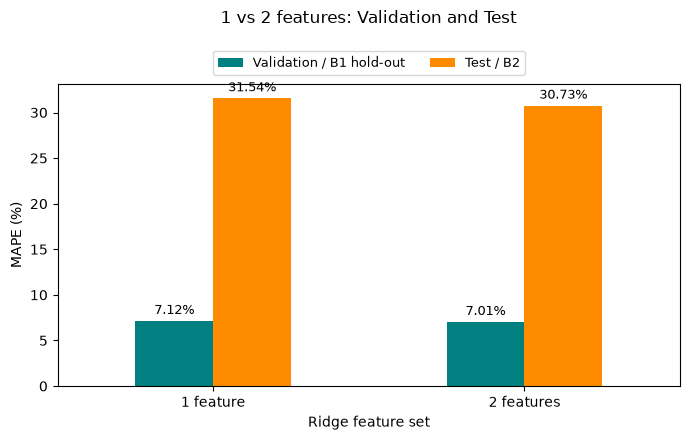

In [19]:
plot_data = comparison.set_index("Feature_set")[["Validation_MAPE_pct", "Test_MAPE_pct"]]
ax = plot_data.plot.bar(figsize=(7, 4.5), color=["teal", "darkorange"], rot=0)
ax.set(xlabel="Ridge feature set", ylabel="MAPE (%)")
ax.set_title("1 vs 2 features: Validation and Test", pad=44)
ax.legend(["Validation / B1 hold-out", "Test / B2"], loc="lower center",
          bbox_to_anchor=(0.5, 1.01), ncol=2, fontsize=9)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=9)
ax.figure.tight_layout()
if SAVE_OUTPUTS:
    ax.figure.savefig(OUT / "validation_test_comparison.png", dpi=150)
plt.show()

### 데이터와 결과 해석

현재 로컬 원본 수명에는 공식 셀 병합·수명 보정을 적용하지 않았고, 로컬 Batch 2는 2018-02-20 데이터로
논문의 Batch 2 코호트와 다릅니다. 이전 EDA에서 hold-out과 Batch 2도 확인했으므로 완전히 처음 보는 데이터로 해석하지 않습니다.
논문의 9.1%는 과제의 **참고 목표**로 비교합니다.

여기까지가 기본 실습입니다. 아래 부록은 설정 선택에 쓰인 CV 점수와 성능 보고용 CV 점수를 분리하여 과제 표를 만듭니다.

## 10. 기본 결과 저장

두 모델을 모두 보관하며, 파일마다 선택한 피처와 alpha를 기록합니다.
저장한 Pipeline에는 학습된 중앙값 대체·표준화·Ridge가 함께 들어갑니다.

`SAVE_OUTPUTS=False`에서는 다음 셀이 설정을 메모리에 보관하고 파일 저장은 건너뜁니다.

In [20]:
split_membership_frames = []
for split_name, frame in [("B1 development", df_train), ("B1 hold-out", df_valid), ("B2 external evaluation", df_test)]:
    membership = frame[["cell_uid", "batch_id", "policy_group", TARGET]].copy()
    membership["split"] = split_name
    split_membership_frames.append(membership)
split_membership = pd.concat(split_membership_frames, ignore_index=True)
main_outputs = {
    "cohort_audit.csv": cohort_audit, "excluded_cells.csv": excluded_cells,
    "split_membership.csv": split_membership, "shared_tuning_fold_membership.csv": cv_fold_membership,
    "tuning_cv_trials.csv": tuning_trials, "tuning_cv_scores.csv": tuning_scores,
    "tuning_choices.csv": tuning_choices, "validation_predictions.csv": validation_predictions,
    "test_predictions.csv": test_predictions, "evaluation_metrics.csv": evaluation_metrics,
    "comparison.csv": comparison,
}
model_filenames = {"1 feature": "ridge_1feature.joblib", "2 features": "ridge_2features.joblib"}

config = {
    "feature_sets": FEATURE_SETS, "target": TARGET, "target_transform": "identity", "model": "Ridge",
    "selected_alphas": best_alphas, "alpha_candidates": ALPHAS, "CV_candidate": selected_feature_set,
    "selection_metric": "Tuning_CV_MAPE_pct", "validation_or_test_used_for_selection": False,
    "seed": SEED, "holdout_group_fraction": 0.2, "tuning_group_folds": 3,
    "B1_development_cells": len(y_train), "B1_holdout_cells": len(y_valid),
    "final_fit_B1_cells": len(y_full), "B2_evaluation_cells": len(y_test),
    "B3_used_for_training_or_evaluation": False,
    "policy_group_definition": "C1 + SOC + C2 + normalized suffix; fallback normalized policy text",
    "policy_metadata_used_as_predictor": False, "paper_target_mape_percent": PAPER_TARGET_MAPE,
    "official_cell_merge_applied": False, "holdout_and_B2_previously_viewed_in_EDA": True,
    "cohort_note": "Raw local cohort; B2 is 2018-02-20, so 9.1% is a reference target.",
    "input_mode": input_mode,
    "extracted_input_sha256": hashlib.sha256(data.to_csv(index=False, float_format="%.17g").encode()).hexdigest(),
    "raw_source_files": {batch_id: {"name": path.name, "size_bytes": path.stat().st_size}
                         for batch_id, path in BATCH_FILES.items()},
    "save_outputs": SAVE_OUTPUTS,
    "model_files": model_filenames,
    "report_url": "https://app.notion.com/p/3ecd54b5a6d7818f99bde98f1cef9db1",
    "nested_cv_completed": False,
}
if SAVE_OUTPUTS:
    for filename, frame in main_outputs.items():
        frame.to_csv(OUT / filename, index=False, encoding="utf-8-sig")
    for feature_set, filename in model_filenames.items():
        joblib.dump(final_models[feature_set], OUT / filename)
    (OUT / "model_config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
    print("기본 결과와 모델 저장 완료:", OUT)
else:
    print("기본 평가와 설정은 노트북에 보관했습니다. 별도 파일 저장은 꺼져 있습니다.")


기본 평가와 설정은 노트북에 보관했습니다. 별도 파일 저장은 꺼져 있습니다.


## 부록 A. 제출용 nested CV

기본 표의 `Tuning_CV_MAPE_pct`는 가장 좋은 설정을 고른 점수입니다.
제출용 성능에서는 개발 36셀에 **바깥 5-fold 평가 / 안쪽 3-fold alpha 선택**을 적용합니다.
안쪽에서 alpha를 고르고, 안쪽에서 사용하지 않은 바깥 검증 데이터로 평가합니다.

두 구성은 바깥·안쪽 폴드까지 모두 같습니다. 각 바깥 폴드마다 alpha를 새로 고르지만,
기본 실습에서 고정한 `best_alphas`와 `CV_candidate`는 바꾸지 않습니다.
아래 `Nested_CV_MAPE_pct`는 바깥 폴드 MAPE 평균이며, `OOF_MAPE_pct`는 36셀 전체의 예측을 모아 계산한 값입니다.
폴드별 셀 수가 달라 두 평균이 약간 다를 수 있습니다.

In [21]:
outer_splits = list(GroupKFold(n_splits=5).split(X_train, y_train, groups_train))
inner_splits_by_outer = []
outer_membership_rows, inner_membership_rows = [], []
for outer_fold, (outer_train_idx, outer_valid_idx) in enumerate(outer_splits, start=1):
    outer_groups = groups_train.iloc[outer_train_idx]
    assert set(outer_groups).isdisjoint(set(groups_train.iloc[outer_valid_idx]))
    inner_splits = list(GroupKFold(n_splits=3).split(
        X_train.iloc[outer_train_idx], y_train.iloc[outer_train_idx], outer_groups))
    inner_splits_by_outer.append(inner_splits)
    for role, indices in [("train", outer_train_idx), ("validation", outer_valid_idx)]:
        for position in indices:
            outer_membership_rows.append({"outer_fold": outer_fold, "role": role,
                                          "cell_uid": df_train.iloc[position]["cell_uid"],
                                          "policy_group": groups_train.iloc[position]})
    for inner_fold, (inner_train_idx, inner_valid_idx) in enumerate(inner_splits, start=1):
        assert set(outer_groups.iloc[inner_train_idx]).isdisjoint(set(outer_groups.iloc[inner_valid_idx]))
        for role, indices in [("train", inner_train_idx), ("validation", inner_valid_idx)]:
            for position in indices:
                original_position = outer_train_idx[position]
                inner_membership_rows.append({"outer_fold": outer_fold, "inner_fold": inner_fold,
                                              "role": role, "cell_uid": df_train.iloc[original_position]["cell_uid"],
                                              "policy_group": groups_train.iloc[original_position]})
nested_outer_membership = pd.DataFrame(outer_membership_rows)
nested_inner_membership = pd.DataFrame(inner_membership_rows)
nested_trials, nested_fold_rows, nested_prediction_frames = [], [], []
print("공통 바깥 5-fold / 각 바깥 학습 데이터 안의 공통 3-fold 준비 완료")

공통 바깥 5-fold / 각 바깥 학습 데이터 안의 공통 3-fold 준비 완료


In [22]:
for feature_set, feature_columns in FEATURE_SETS.items():
    for outer_fold, (outer_train_idx, outer_valid_idx) in enumerate(outer_splits, start=1):
        X_outer_train = X_train.iloc[outer_train_idx][feature_columns]
        y_outer_train = y_train.iloc[outer_train_idx]
        X_outer_valid = X_train.iloc[outer_valid_idx][feature_columns]
        y_outer_valid = y_train.iloc[outer_valid_idx]
        outer_alpha_scores = []

        # 안쪽 CV: 이 바깥 학습 데이터 안에서 alpha 선택
        for alpha in ALPHAS:
            inner_mapes = []
            for inner_fold, (inner_train_idx, inner_valid_idx) in enumerate(inner_splits_by_outer[outer_fold - 1], start=1):
                inner_model = make_model(alpha)
                inner_model.fit(X_outer_train.iloc[inner_train_idx], y_outer_train.iloc[inner_train_idx])
                inner_pred = inner_model.predict(X_outer_train.iloc[inner_valid_idx])
                inner_mape = evaluate(y_outer_train.iloc[inner_valid_idx], inner_pred)["MAPE_pct"]
                inner_mapes.append(inner_mape)
                nested_trials.append({"Feature_set": feature_set, "outer_fold": outer_fold,
                                      "alpha": alpha, "inner_fold": inner_fold, "MAPE_pct": inner_mape})
            outer_alpha_scores.append((float(np.mean(inner_mapes)), float(alpha)))
        _, outer_alpha = min(outer_alpha_scores)

        # 바깥 평가: 선택한 alpha로 재학습 후 보류한 바깥 검증 셀을 예측
        outer_model = make_model(outer_alpha)
        outer_model.fit(X_outer_train, y_outer_train)
        outer_pred = outer_model.predict(X_outer_valid)
        scores = evaluate(y_outer_valid, outer_pred)
        nested_fold_rows.append({"Feature_set": feature_set, "outer_fold": outer_fold,
                                 "selected_alpha": outer_alpha, "valid_cells": len(outer_valid_idx), **scores})
        predictions = df_train.iloc[outer_valid_idx][["cell_uid", "policy_group", TARGET]].copy()
        predictions["Feature_set"] = feature_set
        predictions["outer_fold"] = outer_fold
        predictions["predicted"] = outer_pred
        nested_prediction_frames.append(predictions)
nested_trials = pd.DataFrame(nested_trials)
nested_fold_scores = pd.DataFrame(nested_fold_rows)
nested_oof_predictions = pd.concat(nested_prediction_frames, ignore_index=True)
display(nested_fold_scores.round(4))

,Feature_set,outer_fold,selected_alpha,valid_cells,MAPE_pct,MAE_cycles,RMSE_cycles,R2
0,1 feature,1,0.01,7,10.9654,118.6118,147.4361,0.4084
1,1 feature,2,0.01,8,10.0402,84.8019,101.1790,0.8187
2,1 feature,3,0.01,8,9.0366,68.5123,79.7101,0.4206
3,1 feature,4,0.01,7,11.1469,107.8611,122.7800,-0.5584
4,1 feature,5,0.01,6,6.7579,40.2174,47.7866,0.9013
5,2 features,1,1.00,7,10.2163,109.7651,135.7379,0.4985
6,2 features,2,0.01,8,12.0641,101.0402,116.5478,0.7594
7,2 features,3,0.01,8,9.4048,71.5527,80.9861,0.4019
8,2 features,4,0.01,7,11.2370,108.8327,123.9960,-0.5894
9,2 features,5,0.01,6,5.9814,36.1186,41.9006,0.9241


In [23]:
nested_summary = nested_fold_scores.groupby("Feature_set", as_index=False).agg(
    Nested_CV_MAPE_pct=("MAPE_pct", "mean"), Nested_CV_MAPE_std_pp=("MAPE_pct", "std"))
oof_rows = []
for feature_set in FEATURE_SETS:
    oof = nested_oof_predictions.loc[nested_oof_predictions["Feature_set"].eq(feature_set)]
    assert len(oof) == len(df_train) and oof["cell_uid"].is_unique
    assert set(oof["cell_uid"]) == set(df_train["cell_uid"])
    scores = evaluate(oof[TARGET], oof["predicted"])
    oof_rows.append({"Feature_set": feature_set, "OOF_MAPE_pct": scores["MAPE_pct"],
                     "OOF_MAE_cycles": scores["MAE_cycles"], "OOF_RMSE_cycles": scores["RMSE_cycles"], "OOF_R2": scores["R2"]})
nested_oof_metrics = pd.DataFrame(oof_rows)
nested_summary = nested_summary.merge(nested_oof_metrics[["Feature_set", "OOF_MAPE_pct"]],
                                      on="Feature_set", validate="one_to_one")
display(nested_summary.round(4))
print("기본 표의 튜닝 CV와 부록의 nested CV는 서로 다른 목적으로 계산한 점수입니다.")

,Feature_set,Nested_CV_MAPE_pct,Nested_CV_MAPE_std_pp,OOF_MAPE_pct
0,1 feature,9.5894,1.7920,9.6652
1,2 features,9.7807,2.3505,9.9392


기본 표의 튜닝 CV와 부록의 nested CV는 서로 다른 목적으로 계산한 점수입니다.


## 부록 B. 과제 제출용 성능 결과

각 구성의 Train은 **Nested CV 검증 폴드 MAPE 평균**, Valid는 Batch 1 hold-out, Test는 Batch 2입니다.
Train은 개발 36셀의 바깥 5-fold 평가 평균이며, 기본 표의 alpha 선택용 `Tuning_CV_MAPE_pct`와 구분합니다.
GAP은 `Valid − CV`, `Test − Valid`, `Test − 9.1`로 계산합니다.
**GAP 단위는 %p이며 양수는 오차가 커졌다는 뜻**입니다.

아래 6행 표의 수치는 앞에서 계산한 평가 결과로 자동 생성합니다.
`Gap (Train-Valid)`가 양수이면 과적합을 의심할 수 있지만, CV와 hold-out의 데이터 차이도 있으므로 이 값만으로 단정하지 않습니다.

In [24]:
day2_rows = []
for feature_set in FEATURE_SETS:
    cv_mape = float(nested_summary.loc[nested_summary["Feature_set"].eq(feature_set), "Nested_CV_MAPE_pct"].iloc[0])
    valid_mape = float(validation_scores[feature_set]["MAPE_pct"])
    test_mape = float(test_scores[feature_set]["MAPE_pct"])
    for item, value, unit in [
        ("Train (Batch 1 Nested CV)", cv_mape, "%"),
        ("Valid (Batch 1 hold-out)", valid_mape, "%"),
        ("Test (Batch 2)", test_mape, "%"),
        ("GAP (Train-Valid)", valid_mape - cv_mape, "%p"),
        ("GAP (Valid-Test)", test_mape - valid_mape, "%p"),
        ("GAP (Target-Test)", test_mape - PAPER_TARGET_MAPE, "%p"),
    ]:
        day2_rows.append({"Feature_set": feature_set, "item": item, "value": value, "unit": unit})
day2_performance = pd.DataFrame(day2_rows)

# 과제 양식: 6개 항목을 행으로, 두 피처 구성을 열로 배치합니다.
report_items = [
    "Train (Batch 1 Nested CV)", "Valid (Batch 1 hold-out)", "Test (Batch 2)",
    "GAP (Train-Valid)", "GAP (Valid-Test)", "GAP (Target-Test)",
]
day2_report_table = day2_performance.pivot(index="item", columns="Feature_set", values="value").reindex(
    index=report_items, columns=list(FEATURE_SETS)
)
day2_report_table.columns = ["ΔQ 로그 1피처", "ΔQ 로그 + SOC 2피처"]
day2_report_table.index = pd.Index([
    "Train (Batch 1 CV)", "Valid (Batch 1 Hold-out)", "Test (Batch 2)",
    "Gap (Train-Valid)", "Gap (Valid-Test)", "Gap (Target-Test)",
], name="항목")
day2_report_table["단위"] = ["%", "%", "%", "%p", "%p", "%p"]
day2_report_table["계산·해석"] = [
    "성능 보고용 nested CV의 바깥 5-fold MAPE 평균",
    "Batch 1 hold-out MAPE (10셀)",
    "Batch 2 MAPE (39셀)",
    "Valid − Train; (+) 과적합 의심",
    "Test − Valid; (+) 배치간 일반화 저하 의심",
    "Test − 9.1; (+) 참고 목표보다 높은 오차",
]
display(day2_report_table.round(4))
print("앞의 3개 성능은 MAPE(%), 뒤의 3개 GAP은 퍼센트포인트(%p)입니다.")
print("Target = 9.1% (원논문 참고 목표)")
print("GAP의 (+)는 비교 기준보다 MAPE가 높아졌다는 뜻입니다.")

,ΔQ 로그 1피처,ΔQ 로그 + SOC 2피처,단위,계산·해석
항목,,,,
Train (Batch 1 CV),9.5894,9.7807,%,성능 보고용 nested CV의 바깥 5-fold MAPE 평균
Valid (Batch 1 Hold-out),7.1218,7.0074,%,Batch 1 hold-out MAPE (10셀)
Test (Batch 2),31.5374,30.7252,%,Batch 2 MAPE (39셀)
Gap (Train-Valid),-2.4676,-2.7734,%p,Valid − Train; (+) 과적합 의심
Gap (Valid-Test),24.4156,23.7178,%p,Test − Valid; (+) 배치간 일반화 저하 의심
Gap (Target-Test),22.4374,21.6252,%p,Test − 9.1; (+) 참고 목표보다 높은 오차


앞의 3개 성능은 MAPE(%), 뒤의 3개 GAP은 퍼센트포인트(%p)입니다.
Target = 9.1% (원논문 참고 목표)
GAP의 (+)는 비교 기준보다 MAPE가 높아졌다는 뜻입니다.


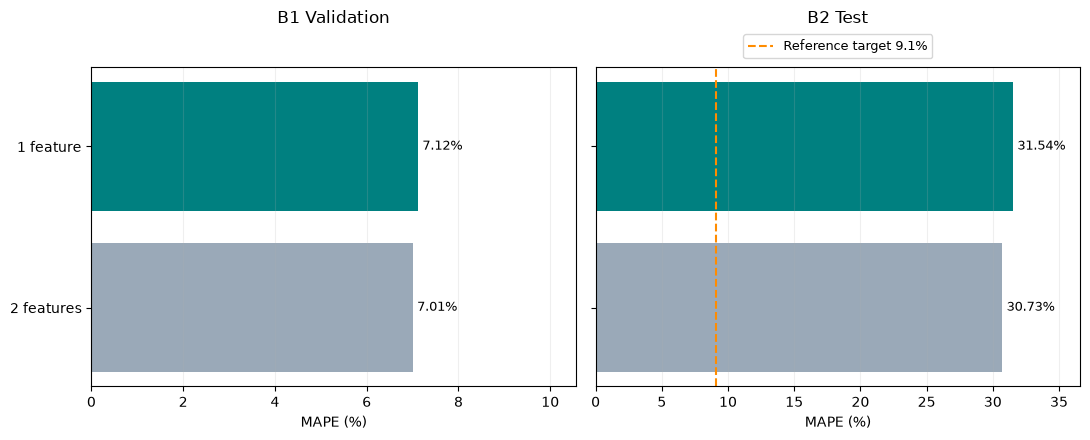

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

required_names = ["validation_scores", "test_scores", "FEATURE_SETS", "selected_feature_set",
                  "PAPER_TARGET_MAPE", "SAVE_OUTPUTS", "OUT"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    print("모델 평가 결과가 아직 없습니다. Restart Kernel → Run All로 위에서부터 실행하세요.")
else:
    report_plot_data = pd.DataFrame({
        "Valid_MAPE_pct": {name: validation_scores[name]["MAPE_pct"] for name in FEATURE_SETS},
        "Test_MAPE_pct": {name: test_scores[name]["MAPE_pct"] for name in FEATURE_SETS},
    })
    plot_colors = ["teal" if name == selected_feature_set else "#9AA9B8" for name in report_plot_data.index]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
    for ax, metric, title in zip(
        axes,
        ["Valid_MAPE_pct", "Test_MAPE_pct"],
        ["B1 Validation", "B2 Test"],
    ):
        bars = ax.barh(report_plot_data.index, report_plot_data[metric], color=plot_colors)
        ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=9)
        max_mape = report_plot_data[metric].max()
        ax.set(xlabel="MAPE (%)", xlim=(0, max(max_mape, PAPER_TARGET_MAPE) * 1.16))
        ax.set_title(title, pad=32)
        ax.grid(axis="x", alpha=0.2)
    axes[0].invert_yaxis()
    axes[1].axvline(PAPER_TARGET_MAPE, color="darkorange", linestyle="--", label="Reference target 9.1%")
    axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), fontsize=9)
    fig.tight_layout()
    if SAVE_OUTPUTS:
        fig.savefig(OUT / "day2_validation_test_mape.png", dpi=150)
    plt.show()


위 그래프는 앞의 학습·평가 결과를 사용합니다. 새 커널에서는 `pandas`뿐 아니라
성능 변수도 없어지므로 **Restart Kernel → Run All**로 실행하세요.
그래프 셀만 먼저 실행하면 필요한 실행 순서를 안내합니다.

## 부록 C. CV 결과 저장

`SAVE_OUTPUTS=True`이면 폴드의 셀 목록, 안쪽 alpha 비교, 바깥 평가 결과와 6행 과제 표를 저장합니다.
기본값 `False`에서는 화면의 결과만 확인하며 별도 결과 폴더를 만들지 않습니다.


In [26]:
appendix_outputs = {
    "shared_nested_outer_fold_membership.csv": nested_outer_membership,
    "shared_nested_inner_fold_membership.csv": nested_inner_membership,
    "nested_inner_trials.csv": nested_trials, "nested_cv_fold_scores.csv": nested_fold_scores,
    "nested_oof_predictions.csv": nested_oof_predictions, "nested_oof_metrics.csv": nested_oof_metrics,
    "nested_cv_summary.csv": nested_summary, "day2_performance.csv": day2_performance,
    "day2_report_table.csv": day2_report_table.reset_index(),
}
config.update({"nested_cv_completed": True, "reporting_outer_group_folds": 5, "reporting_inner_group_folds": 3,
               "reporting_metric": "Nested_CV_MAPE_pct = mean outer-fold MAPE"})
if SAVE_OUTPUTS:
    for filename, frame in appendix_outputs.items():
        frame.to_csv(OUT / filename, index=False, encoding="utf-8-sig")
    (OUT / "model_config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
    print("전체 결과 저장 완료:", OUT)
else:
    print("과제 6행 표까지 계산 완료. 별도 결과 파일은 저장하지 않았습니다.")


과제 6행 표까지 계산 완료. 별도 결과 파일은 저장하지 않았습니다.
